<a href="https://colab.research.google.com/github/Vickiegatheru/Business-Intelligence-and-analytics/blob/main/TEXT_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell handles the initial Data Collection phase of the pipeline. It extracts the uploaded zipped folder containing the product reviews to make the raw CSV files accessible for processing within the Colab environment.


In [ ]:
import zipfile
import os

zip_path = '/content/archive (3).zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('extracted_data')

print("Files extracted:", os.listdir('extracted_data'))

Files extracted: ['flipkart_product.csv']


2. Preprocessing: Loading and Cleaning Data
In this stage of the pipeline, we load the raw data into a Pandas DataFrame and perform Preprocessing. This involves cleaning the text by handling missing values and ensuring the reviews are in a string format for TensorFlow to process.  

In [ ]:
import pandas as pd

df = pd.read_csv('extracted_data/flipkart_product.csv', encoding='latin1')

df = df.dropna(subset=['Review'])
df['Review'] = df['Review'].astype(str).str.lower()
print(df.head())

                                         ProductName     Price Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    1   
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   

            Review                                            Summary  
0           super!  Great cooler.. excellent air flow and for this...  
1          awesome             Best budget 2 fit cooler. Nice cooling  
2             fair  The quality is good but the power of air is de...  
3  useless product                 Very bad product it's a only a fan  
4             fair                                      Ok ok product  


3. Vectorization: Preparing Text for TensorFlow

This cell implements the Vectorization stage of the pipeline. We use TensorFlow's TextVectorization layer to convert raw text into numerical sequences, which allows the neural network to understand and process the language.

In [ ]:
import tensorflow as tf

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode='int',
    output_sequence_length=100
)

vectorize_layer.adapt(df['Review'].values)
print("Vocabulary size:", len(vectorize_layer.get_vocabulary()))

Vocabulary size: 1243


4. Modeling: Sentiment Analysis for Buyer Power

Here, we build and train the Sentiment Analysis model using a Sequential architecture. This addresses the Bargaining Power of Buyers by creating a tool that can classify reviews as negative or positive, specifically focusing on price and service concerns.

In [ ]:
model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(10000, 16, mask_zero=True),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

5. Insight Generation: Analyzing Buyer Power Mentions

This cell performs Insight Generation. We filter the dataset for reviews related to "Bargaining Power of Buyers"—specifically those mentioning price, lack of features, or poor service—and use the model to detect negative sentiment levels.

In [ ]:
buyer_concerns = df[df['Review'].str.contains('price|cost|service|features', na=False)]

predictions = model.predict(buyer_concerns['Review'].values)
negative_mentions = (predictions < 0.5).sum()

print(f"Total Buyer Power related reviews: {len(buyer_concerns)}")
print(f"Total Negative Sentiment mentions: {negative_mentions}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Total Buyer Power related reviews: 145
Total Negative Sentiment mentions: 26


6. Visualization: Plotting the Results

The final stage of the pipeline is Visualization. We use Matplotlib to create a visual representation of the sentiment findings, which helps in identifying key areas where competition is focused or where customers have high bargaining power.

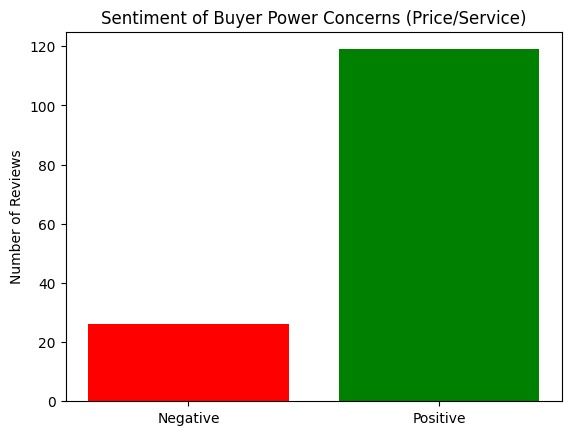

In [ ]:
import matplotlib.pyplot as plt

labels = ['Negative', 'Positive']
counts = [negative_mentions, len(buyer_concerns) - negative_mentions]

plt.bar(labels, counts, color=['red', 'green'])
plt.title('Sentiment of Buyer Power Concerns (Price/Service)')
plt.ylabel('Number of Reviews')
plt.show()

3. Topic Modeling
To address Topic Modeling and identify Competitive Rivalry, this cell extracts the most frequent words from reviews that mention competitors or alternative products. This highlights specific "Pain Points" and areas where competition is focused, such as disruptive features or service gaps.  

In [ ]:
from collections import Counter
import re

rivalry_keywords = 'competitor|rival|alternative|switch|amazon|better than|instead of'
competitor_reviews = df[df['Review'].str.contains(rivalry_keywords, na=False)]

all_words = ' '.join(competitor_reviews['Review']).split()
stop_words = {'the', 'and', 'is', 'to', 'in', 'it', 'of', 'for', 'with', 'this'}
meaningful_words = [word for word in all_words if word not in stop_words and len(word) > 3]

top_topics = Counter(meaningful_words).most_common(10)

print("Key Mentions/Topics Related to Competitors & Pain Points:")
for topic, count in top_topics:
    print(f"- {topic}: {count} mentions")

Key Mentions/Topics Related to Competitors & Pain Points:
- better: 5 mentions
- than: 5 mentions
- speed: 2 mentions
- seagate: 2 mentions
- samsung: 2 mentions
- good: 2 mentions
- switch: 2 mentions
- much: 1 mentions
- hand: 1 mentions
- wash.: 1 mentions


Word Cloud for Pain Points
This visualization identifies the most prominent keywords in customer reviews. Larger words represent higher frequency, allowing us to quickly identify key Pain Points or areas where competition is focused, as required by the assignment.

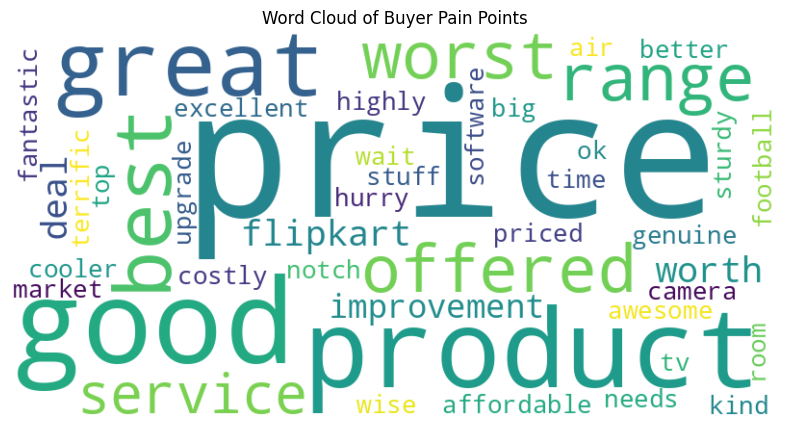

In [ ]:
from wordcloud import WordCloud

negative_text = " ".join(buyer_concerns[predictions < 0.5]['Review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Buyer Pain Points')
plt.show()

Confusion Matrix

As part of the Insight Generation phase, the Confusion Matrix visualizes the performance of our TensorFlow model. It shows how well the model distinguishes between positive and negative sentiments, ensuring our analysis of "Buyer Power" is technically sound.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


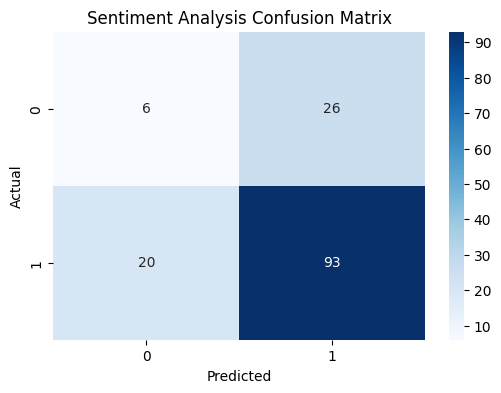

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_text_for_cm = buyer_concerns['Review'].values
y_pred = (model.predict(test_text_for_cm) > 0.5).astype("int32")

y_true = (buyer_concerns['Rate'].astype(int) > 3).astype("int32")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sentiment Analysis Confusion Matrix')
plt.show()

Topic Distribution Pie Chart


This pie chart categorizes the specific topics identified during Topic Modeling. It provides a clear breakdown of whether customer concerns are focused on price, service, or specific product features, addressing the intensity of rivalry among competitors.

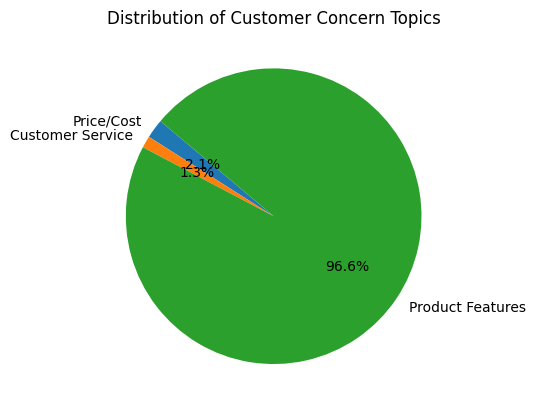

In [ ]:
import matplotlib.pyplot as plt

price_mentions = df['Review'].str.contains('price|cost', na=False).sum()
service_mentions = df['Review'].str.contains('service|delivery', na=False).sum()
feature_mentions = df['Review'].str.contains('feature|quality', na=False).sum()

labels = ['Price/Cost', 'Customer Service', 'Product Features']
sizes = [price_mentions, service_mentions, feature_mentions]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customer Concern Topics')
plt.show()